In [1]:
import sys
sys.path.append("..")  # add project root
from prog import mlps, featlib, trainer, hlprs
import Datasets.matconv as mc
import Datasets.load_mat_as_flat as lmf
import torch
import matplotlib.pyplot as plt
import numpy as np

MLP/Training Settings
- controlled for all noise tests

In [2]:
selected_derivs=('u','u_x','u_xx') # up to first order derivative inputs
lr=0.001
batch_size=1000  # number of data points used on optimization step 
                 # data points are generated according to tensor.randint over spacetime mesh
lam_pde=0.5
lam_reg=0.0
lam_tv=0.0
lam_data=10.0

#output settings
log_every=1000

In [3]:
device='cpu'

Noise tests: 
Values for noise = 0.05, 0.01, 0.1, 0.5 

Noise is added according to 


`sigma = noise_level * np.std(y_s)`

`y_noisy = y_s + sigma * np.random.randn(*y_s.shape)`

$y_s$ are data values at some space time point $(x_i,t_i)$ 

This way noise addition is scaled as opposed to just applying `noise_level` to `np.random.randn`


Test 1: 0.05

In [4]:
data_path = "../Datasets/data/raw/burgers.mat"
partitions = lmf.load_burgers_mat_as_flat(data_path,noise_level=noise,stride_t=stride_t,stride_x=stride_x,seed=seed,quantile_splits=part_num,return_partitions=True,)
t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f"Q{which_part}:")][0]]


NameError: name 'noise' is not defined

In [ ]:
# Data generation settings

noise=0.05
nu=0.02
stride_t=15
stride_x=15
part_num=1
which_part=1
seed=1432


# Dataset building

partitions = mc.build_dataset_from_burgers(noise_level=noise, nu=nu, stride_t=stride_t, stride_x=stride_x, seed=seed, quantile_splits=part_num, return_partitions=True)
t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]
# batches are generated over t_np, x_np, y_np, y_noisy_np

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

In [7]:
# Initializing u_model and symnet

train_config=trainer.TrainerConfig(
    lr=lr,
    lambda_pde=lam_pde, 
    lambda_reg=lam_reg,
    lambda_tv=lam_tv, 
    lambda_data=lam_data, 
    selected_derivs=selected_derivs, 
)

u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64)
symnet=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False) # dummy v_model for working code

ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=symnet,cfg=train_config, feature_builder=feature_builder)


In [ ]:
loss_ps = []
loss_dat = []
for i in range(4000): 
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,t_torch=t_torch,x_torch=x_torch,y_noisy=y_noisy_torch,y_clean=y_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    loss_dat.append(ld)
    loss_ps.append(lp)
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

step 0 data_loss=0.5646110773086548 pde_loss=0.02301337942481041
step 1000 data_loss=0.009529768489301205 pde_loss=0.010850908234715462
step 2000 data_loss=0.0037440659943968058 pde_loss=0.005428627599030733
step 3000 data_loss=0.002941611921414733 pde_loss=0.003601719392463565


max_abs_diff = 0.075222


()

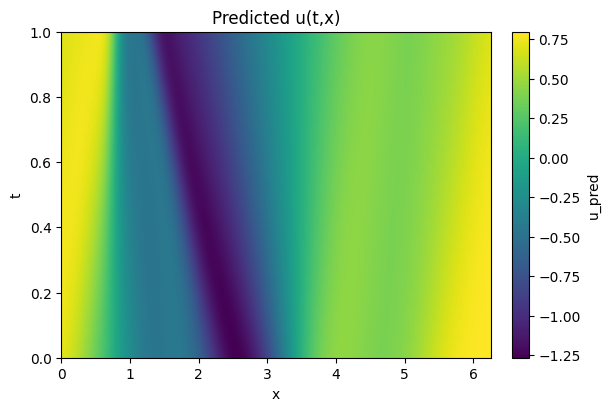

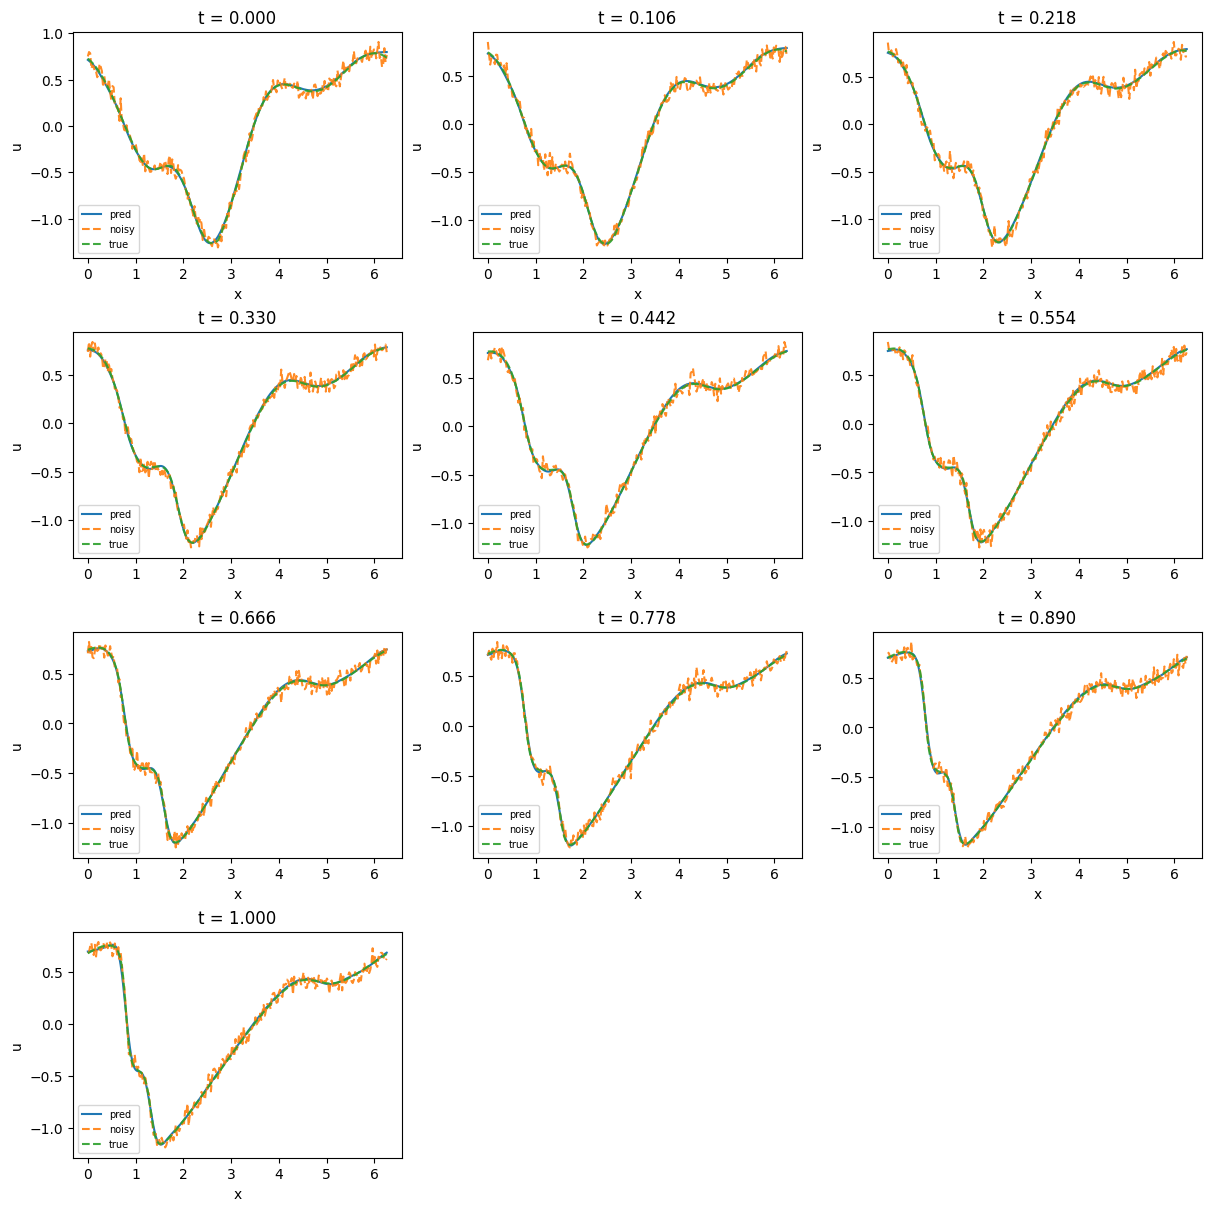

In [ ]:
hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

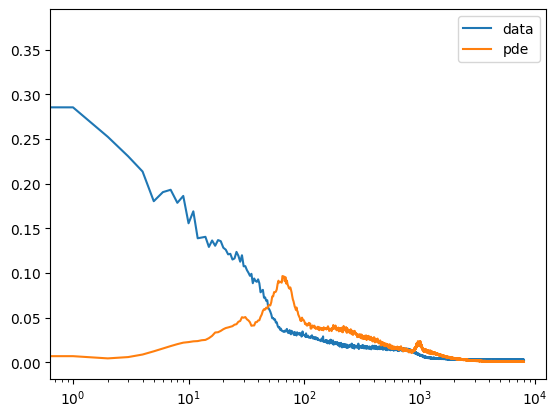

In [ ]:
plt.plot(loss_dat,label='data')
plt.plot(loss_ps,label='pde')
plt.legend()
plt.xscale('log')

In [ ]:
#Coefficient array (outerproduct: [u,u_x,u_xx]^2)
print(symnet.effective_quadratic_matrix()) # already acted on by readout weight
print(symnet.readout.weight) #verify nu value


tensor([[ 4.5364e-03,  2.4445e-05,  4.6623e-05],
        [-9.9596e-01, -5.3668e-03, -1.0236e-02],
        [-4.1848e-03, -2.2550e-05, -4.3009e-05]])
Parameter containing:
tensor([[-0.0122, -0.0045,  0.0065,  0.7430]], requires_grad=True)


Test 2: 0.0 noise
- control
- check outerproduct function (eql) works

In [ ]:
# Data generation settings

noise=0.0
nu=0.02
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432


# Dataset building

partitions = mc.build_dataset_from_burgers(noise_level=noise, nu=nu, stride_t=stride_t, stride_x=stride_x, seed=seed, quantile_splits=part_num, return_partitions=True)
t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]
# batches are generated over t_np, x_np, y_np, y_noisy_np

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

In [ ]:
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64)
symnet=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False) # dummy v_model for working code
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=symnet,cfg=train_config, feature_builder=feature_builder)

In [ ]:
loss_ps = []
loss_dat = []
for i in range(8000): 
    t,x,u_noisy,u_clean = hlprs.make_nonlinear_batch(batch_size=batch_size,t_torch=t_torch,x_torch=x_torch,y_torch=y_noisy_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    loss_dat.append(ld)
    loss_ps.append(lp)
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

step 0 data_loss=0.3648930788040161 pde_loss=0.0004548943543341011
step 1000 data_loss=0.004447754006832838 pde_loss=0.007765883579850197
step 2000 data_loss=0.0003124875365756452 pde_loss=0.0033972354140132666
step 3000 data_loss=0.000161839765496552 pde_loss=0.0011743350187316537
step 4000 data_loss=7.282542355824262e-05 pde_loss=0.0005749493720941246
step 5000 data_loss=6.597291940124705e-05 pde_loss=0.0003806259192060679
step 6000 data_loss=3.7447636714205146e-05 pde_loss=0.00031335395760834217
step 7000 data_loss=2.6773423087433912e-05 pde_loss=0.00024267636763397604


tensor([[ 4.0143e-03, -1.0031e+00, -3.5128e-03],
        [ 1.3077e-05, -3.2676e-03, -1.1443e-05],
        [ 3.2286e-05, -8.0676e-03, -2.8252e-05]])
Parameter containing:
tensor([[-0.0091, -0.0028,  0.0087, -0.6861]], requires_grad=True)
max_abs_diff = 0.0487724


()

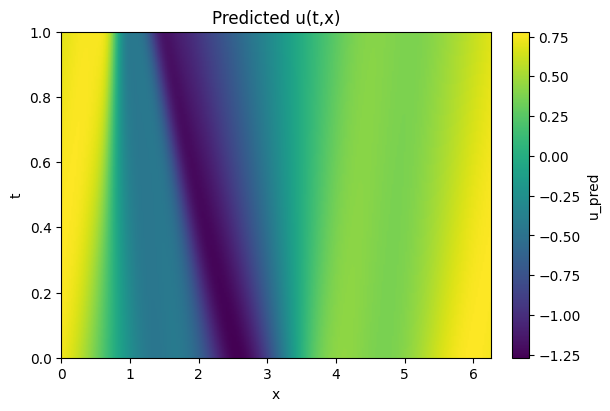

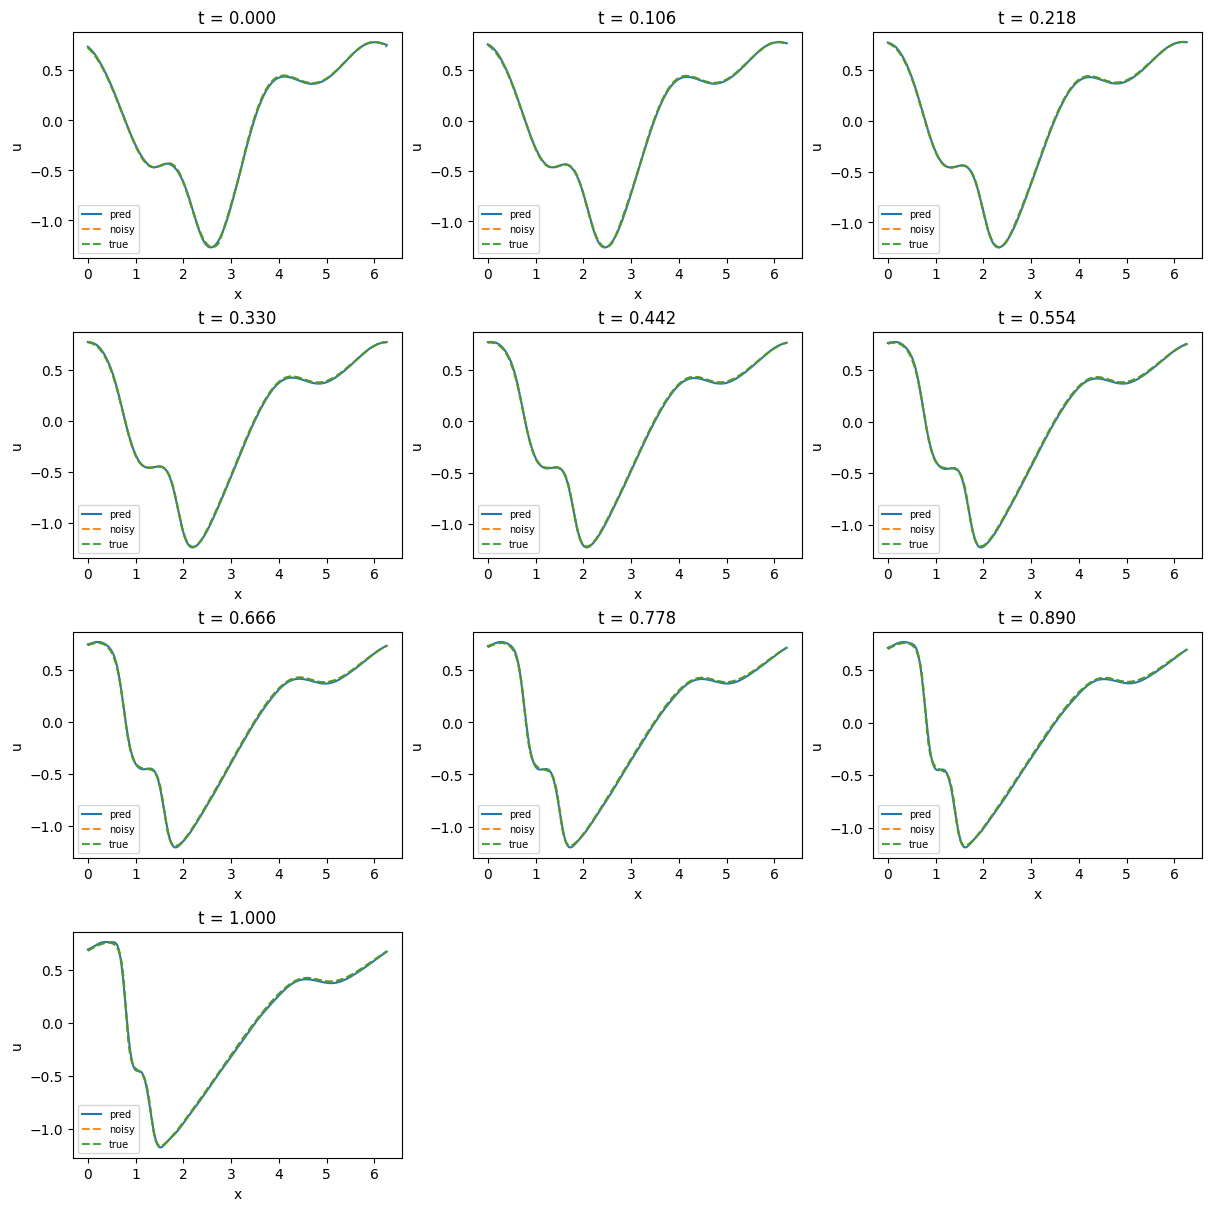

In [ ]:
#Coefficient array (outerproduct: [u,u_x,u_xx]^2)
print(symnet.effective_quadratic_matrix()) # already acted on by readout weight
print(symnet.readout.weight) #verify nu value
hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]


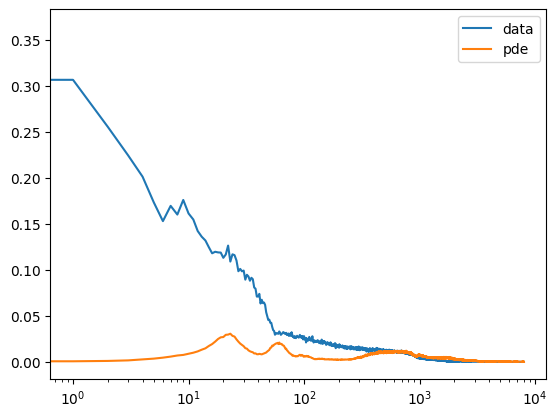

In [ ]:
plt.plot(loss_dat,label='data')
plt.plot(loss_ps,label='pde')
plt.legend()
plt.xscale('log')

Test 3: 0.01 noise

In [ ]:
# Data generation settings

noise=0.01
nu=0.02
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432


# Dataset building

partitions = mc.build_dataset_from_burgers(noise_level=noise, nu=nu, stride_t=stride_t, stride_x=stride_x, seed=seed, quantile_splits=part_num, return_partitions=True)
t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]
# batches are generated over t_np, x_np, y_np, y_noisy_np

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

In [ ]:
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64)
symnet=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False) # dummy v_model for working code
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=symnet,cfg=train_config, feature_builder=feature_builder)

In [ ]:
loss_ps = []
loss_dat = []
for i in range(8000): 
    t,x,u_noisy,u_clean = hlprs.make_nonlinear_batch(batch_size=batch_size,t_torch=t_torch,x_torch=x_torch,y_torch=y_noisy_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    loss_dat.append(ld)
    loss_ps.append(lp)
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

step 0 data_loss=0.4102283716201782 pde_loss=0.0020055007189512253
step 1000 data_loss=0.010230280458927155 pde_loss=0.00850726943463087
step 2000 data_loss=0.0007966926204971969 pde_loss=0.004832366015762091
step 3000 data_loss=0.00034540757769718766 pde_loss=0.0016181524842977524
step 4000 data_loss=0.0002724432561080903 pde_loss=0.0010123264510184526
step 5000 data_loss=0.00016340323782060295 pde_loss=0.0008300376939587295
step 6000 data_loss=0.00017133659275714308 pde_loss=0.0005767085822299123
step 7000 data_loss=0.000167148289619945 pde_loss=0.00044962044921703637


tensor([[ 5.8946e-03,  2.1591e-05,  4.9545e-05],
        [-1.0022e+00, -3.6709e-03, -8.4235e-03],
        [-2.4290e-03, -8.8971e-06, -2.0416e-05]])
Parameter containing:
tensor([[-0.0071, -0.0048,  0.0093, -0.8709]], requires_grad=True)
max_abs_diff = 0.0663101


()

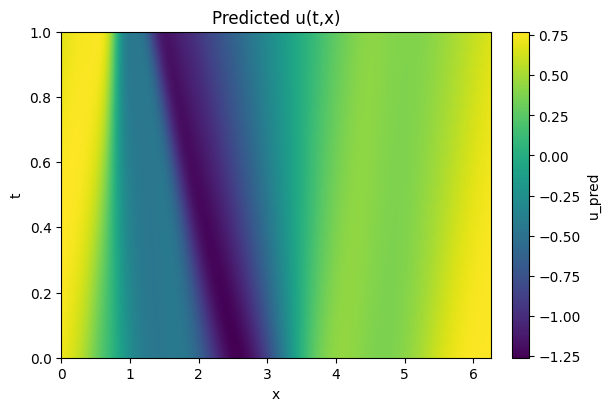

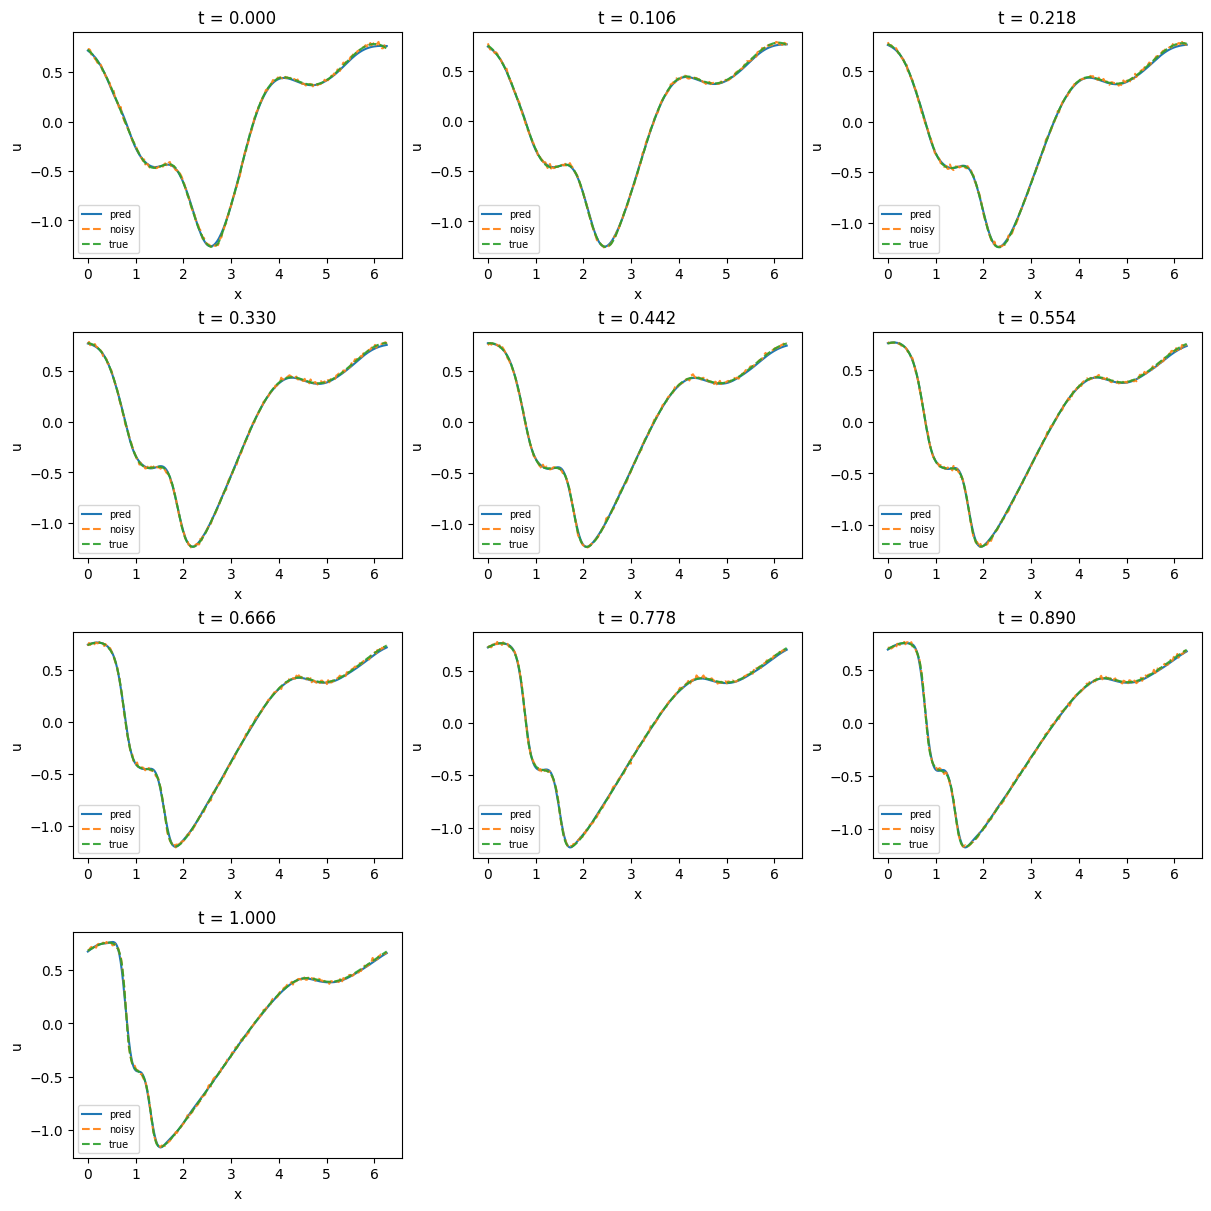

In [ ]:
#Coefficient array (outerproduct: [u,u_x,u_xx]^2)
print(symnet.effective_quadratic_matrix()) # already acted on by readout weight
print(symnet.readout.weight) #verify nu value
hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]


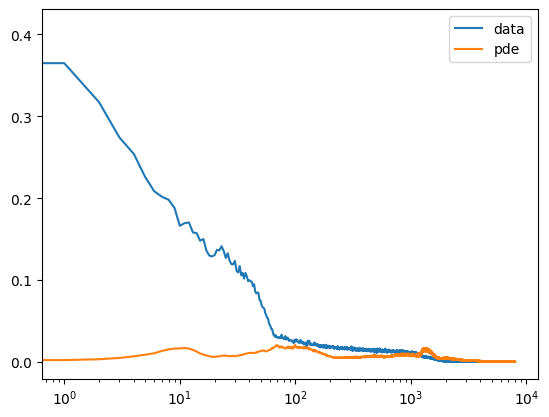

In [ ]:
plt.plot(loss_dat,label='data')
plt.plot(loss_ps,label='pde')
plt.legend()
plt.xscale('log')

Test 4: 0.1 noise

In [ ]:
# Data generation settings

noise=0.1
nu=0.02
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432


# Dataset building

partitions = mc.build_dataset_from_burgers(noise_level=noise, nu=nu, stride_t=stride_t, stride_x=stride_x, seed=seed, quantile_splits=part_num, return_partitions=True)
t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]
# batches are generated over t_np, x_np, y_np, y_noisy_np

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

In [ ]:
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64)
symnet=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False) # dummy v_model for working code
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=symnet,cfg=train_config, feature_builder=feature_builder)

In [ ]:
loss_ps = []
loss_dat = []
for i in range(8000): 
    t,x,u_noisy,u_clean = hlprs.make_nonlinear_batch(batch_size=batch_size,t_torch=t_torch,x_torch=x_torch,y_torch=y_noisy_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    loss_dat.append(ld)
    loss_ps.append(lp)
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

step 0 data_loss=0.5337658524513245 pde_loss=0.0031739859841763973
step 1000 data_loss=0.020698372274637222 pde_loss=0.011431654915213585
step 2000 data_loss=0.010179432108998299 pde_loss=0.008461004123091698
step 3000 data_loss=0.011073880828917027 pde_loss=0.0043729571625590324
step 4000 data_loss=0.009771032258868217 pde_loss=0.0024486163165420294
step 5000 data_loss=0.009977096691727638 pde_loss=0.0015578354941681027
step 6000 data_loss=0.010507947765290737 pde_loss=0.0011399073991924524
step 7000 data_loss=0.010482224635779858 pde_loss=0.0012213281588628888


tensor([[ 1.1901e-02,  4.2145e-05,  1.3405e-04],
        [-9.8898e-01, -3.5022e-03, -1.1139e-02],
        [-2.5293e-03, -8.9569e-06, -2.8489e-05]])
Parameter containing:
tensor([[-0.0049, -0.0081,  0.0069,  0.6117]], requires_grad=True)
max_abs_diff = 0.0721582


()

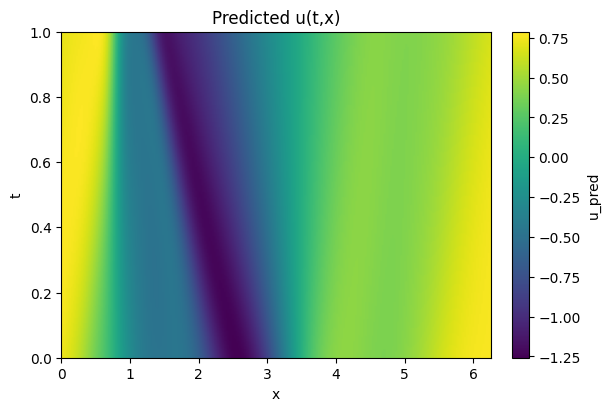

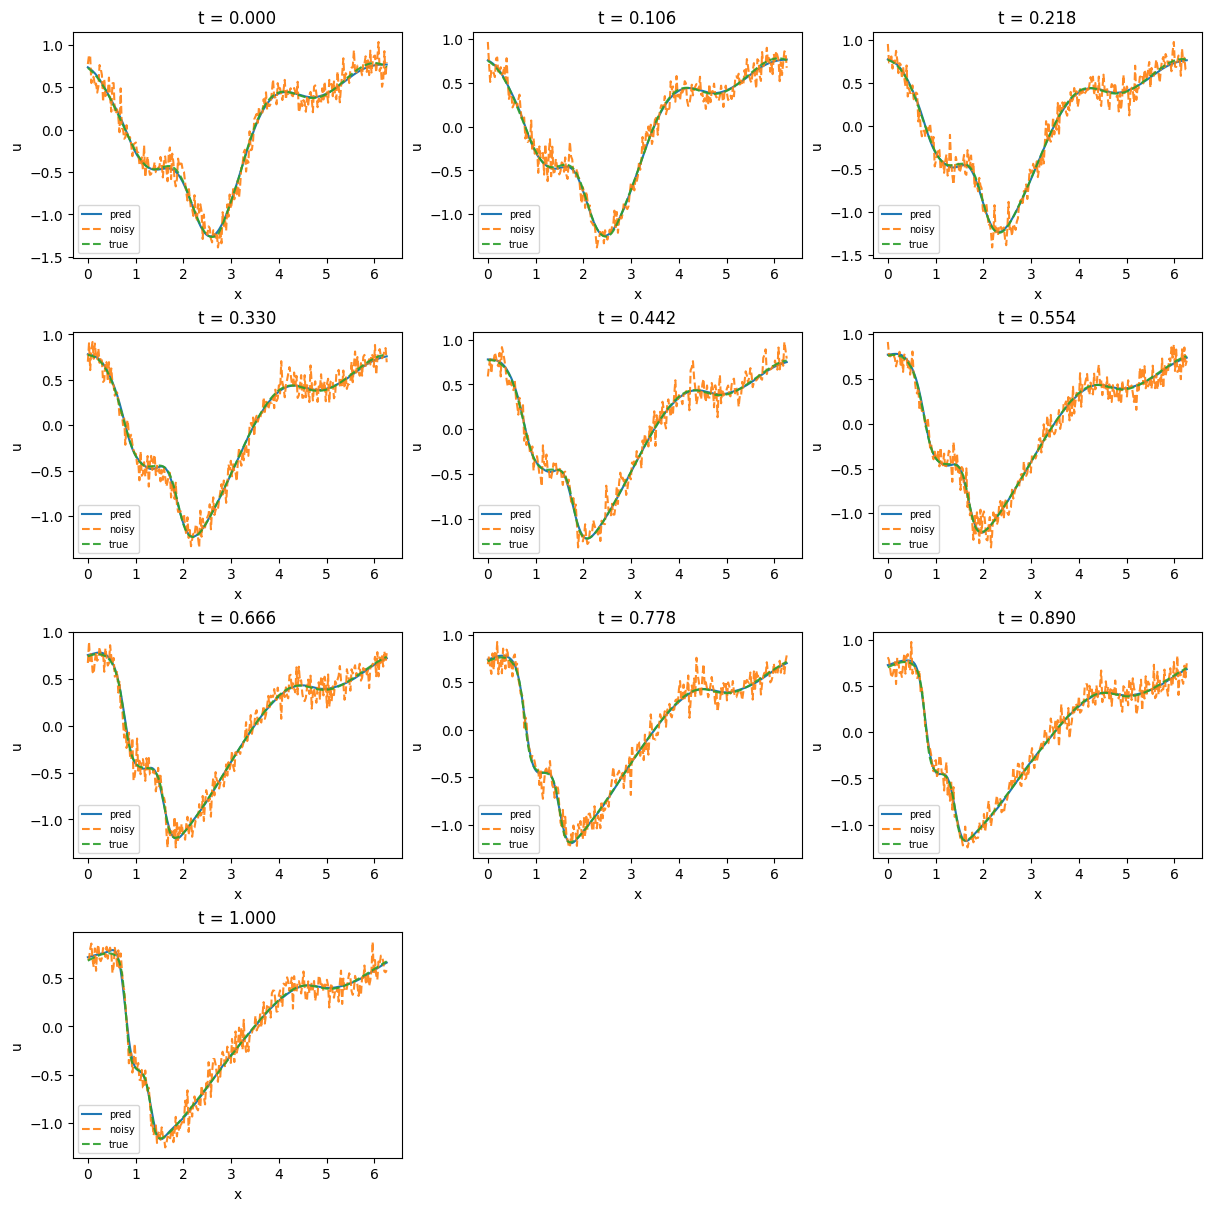

In [ ]:
#Coefficient array (outerproduct: [u,u_x,u_xx]^2)
print(symnet.effective_quadratic_matrix()) # already acted on by readout weight
print(symnet.readout.weight) #verify nu value
hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]


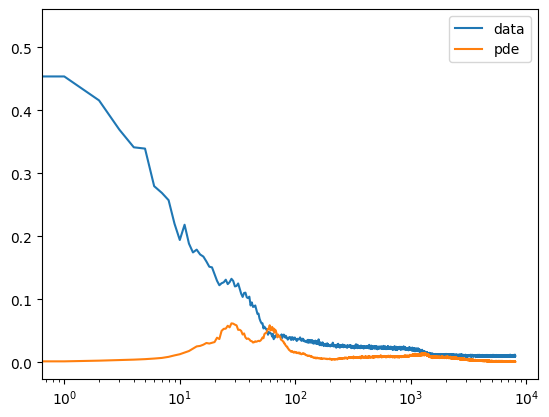

In [ ]:
plt.plot(loss_dat,label='data')
plt.plot(loss_ps,label='pde')
plt.legend()
plt.xscale('log')

Test 5: 0.5 noise

In [ ]:
# Data generation settings

noise=0.5
nu=0.02
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432


# Dataset building

partitions = mc.build_dataset_from_burgers(noise_level=noise, nu=nu, stride_t=stride_t, stride_x=stride_x, seed=seed, quantile_splits=part_num, return_partitions=True)
t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]
# batches are generated over t_np, x_np, y_np, y_noisy_np

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

In [ ]:
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64)
symnet=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False) # dummy v_model for working code
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=symnet,cfg=train_config, feature_builder=feature_builder)

In [ ]:
loss_ps = []
loss_dat = []
for i in range(8000): 
    t,x,u_noisy,u_clean = hlprs.make_nonlinear_batch(batch_size=batch_size,t_torch=t_torch,x_torch=x_torch,y_torch=y_noisy_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    loss_dat.append(ld)
    loss_ps.append(lp)
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

step 0 data_loss=0.5845530033111572 pde_loss=0.0011556826066225767
step 1000 data_loss=0.2535770535469055 pde_loss=0.008592767640948296
step 2000 data_loss=0.23752878606319427 pde_loss=0.005207114387303591
step 3000 data_loss=0.23813892900943756 pde_loss=0.003896422451362014
step 4000 data_loss=0.2520788311958313 pde_loss=0.0033069991040974855
step 5000 data_loss=0.2295917421579361 pde_loss=0.004609785974025726
step 6000 data_loss=0.24685654044151306 pde_loss=0.002715674228966236
step 7000 data_loss=0.2478122115135193 pde_loss=0.002926410175859928


tensor([[-1.7434e-02,  1.0632e-04, -2.3432e-04],
        [-9.5904e-01,  5.8486e-03, -1.2890e-02],
        [-1.2800e-02,  7.8062e-05, -1.7205e-04]])
Parameter containing:
tensor([[-0.0125,  0.0054,  0.0011,  0.7574]], requires_grad=True)
max_abs_diff = 0.134169


()

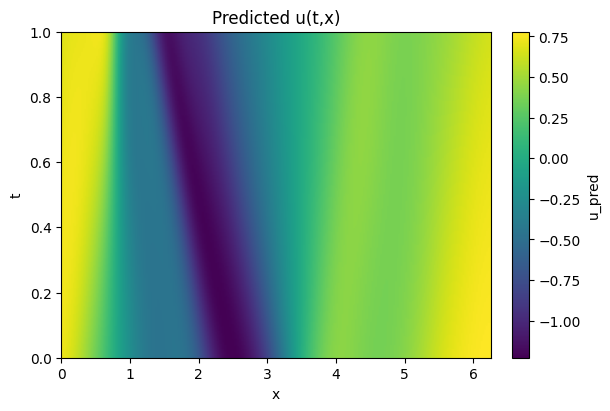

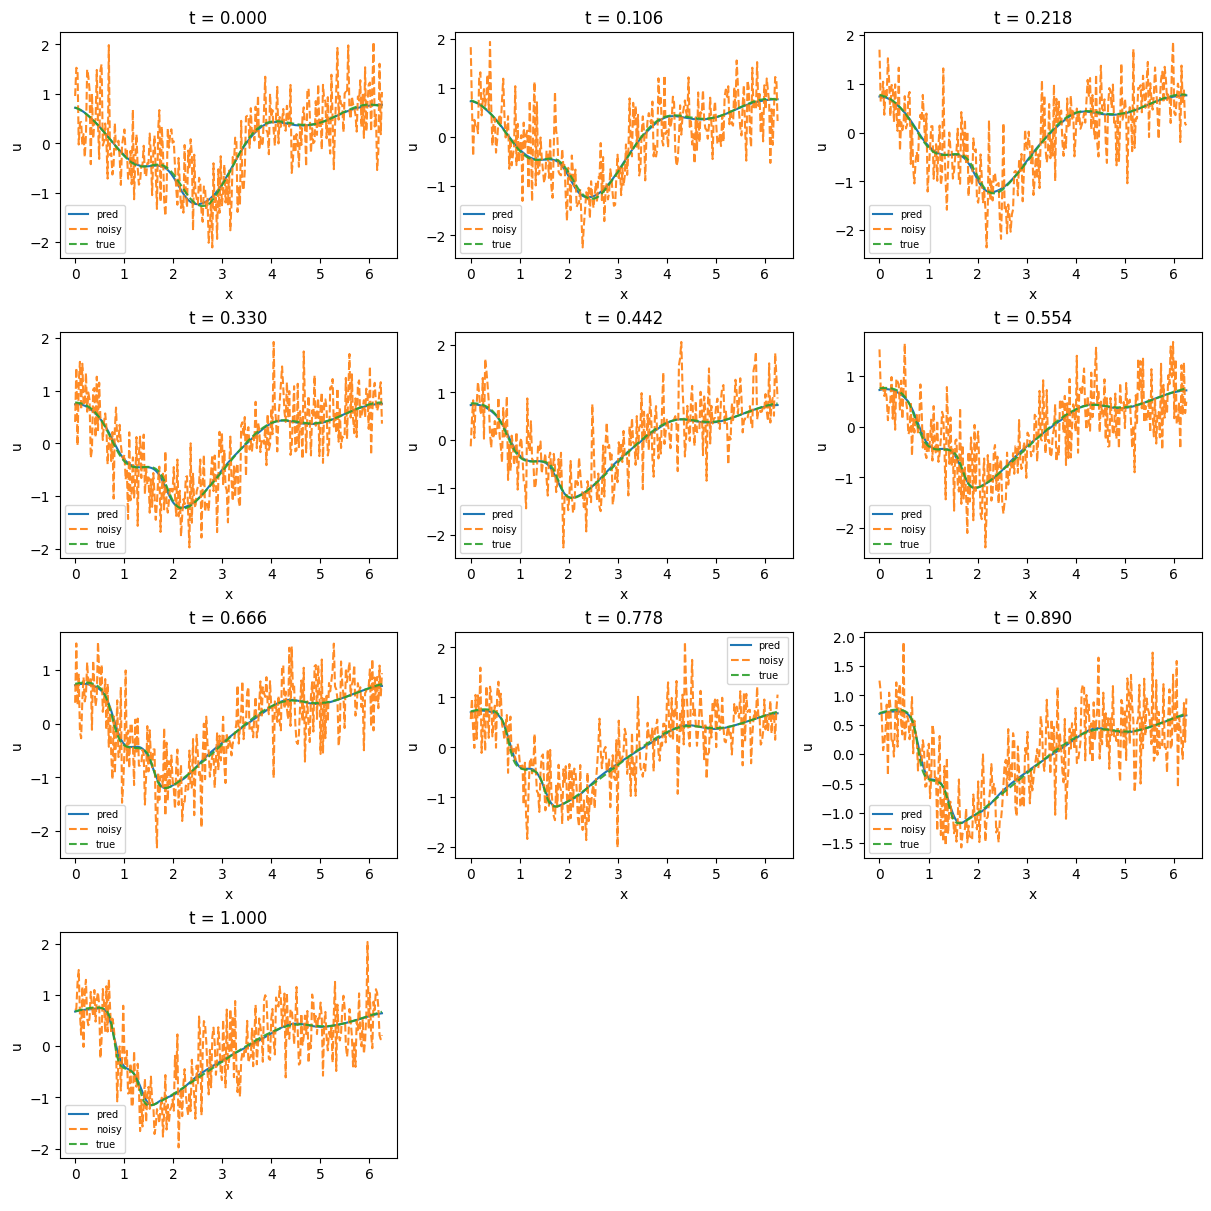

In [ ]:
#Coefficient array (outerproduct: [u,u_x,u_xx]^2)
print(symnet.effective_quadratic_matrix()) # already acted on by readout weight
print(symnet.readout.weight) #verify nu value
hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]


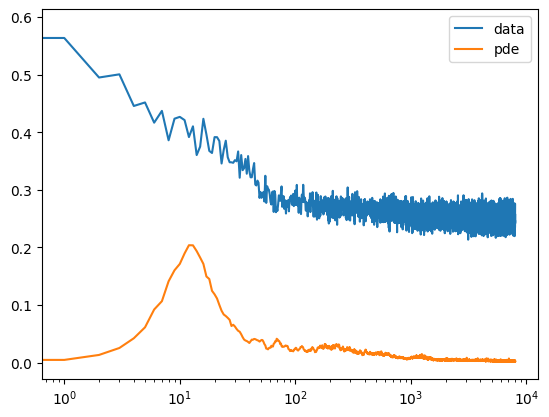

In [ ]:
plt.plot(loss_dat,label='data')
plt.plot(loss_ps,label='pde')
plt.legend()
plt.xscale('log')

Test 5: 0.7

In [ ]:
# Data generation settings

noise=0.7
nu=0.02
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432


# Dataset building

partitions = mc.build_dataset_from_burgers(noise_level=noise, nu=nu, stride_t=stride_t, stride_x=stride_x, seed=seed, quantile_splits=part_num, return_partitions=True)
t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]
# batches are generated over t_np, x_np, y_np, y_noisy_np

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

In [ ]:
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64)
symnet=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False) # dummy v_model for working code
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=symnet,cfg=train_config, feature_builder=feature_builder)

In [ ]:
loss_ps = []
loss_dat = []
for i in range(8000): 
    t,x,u_noisy,u_clean = hlprs.make_nonlinear_batch(batch_size=batch_size,t_torch=t_torch,x_torch=x_torch,y_torch=y_noisy_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    loss_dat.append(ld)
    loss_ps.append(lp)
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

step 0 data_loss=0.8046440482139587 pde_loss=0.009073391556739807
step 1000 data_loss=0.5302445888519287 pde_loss=0.005902985110878944
step 2000 data_loss=0.4599260091781616 pde_loss=0.004088102839887142
step 3000 data_loss=0.5010170340538025 pde_loss=0.0026667052879929543
step 4000 data_loss=0.5183529257774353 pde_loss=0.0030422687996178865
step 5000 data_loss=0.5068948864936829 pde_loss=0.00365792540833354
step 6000 data_loss=0.5263547897338867 pde_loss=0.003104995936155319
step 7000 data_loss=0.5075968503952026 pde_loss=0.003181180916726589


tensor([[ 2.2724e-02,  1.5295e-04,  4.1008e-04],
        [-8.9696e-01, -6.0372e-03, -1.6186e-02],
        [-1.1292e-02, -7.6005e-05, -2.0378e-04]])
Parameter containing:
tensor([[-0.0125,  0.0099, -0.0041, -0.8305]], requires_grad=True)
max_abs_diff = 0.132846


()

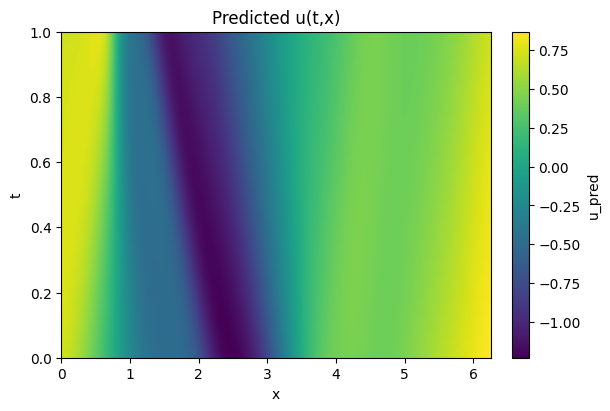

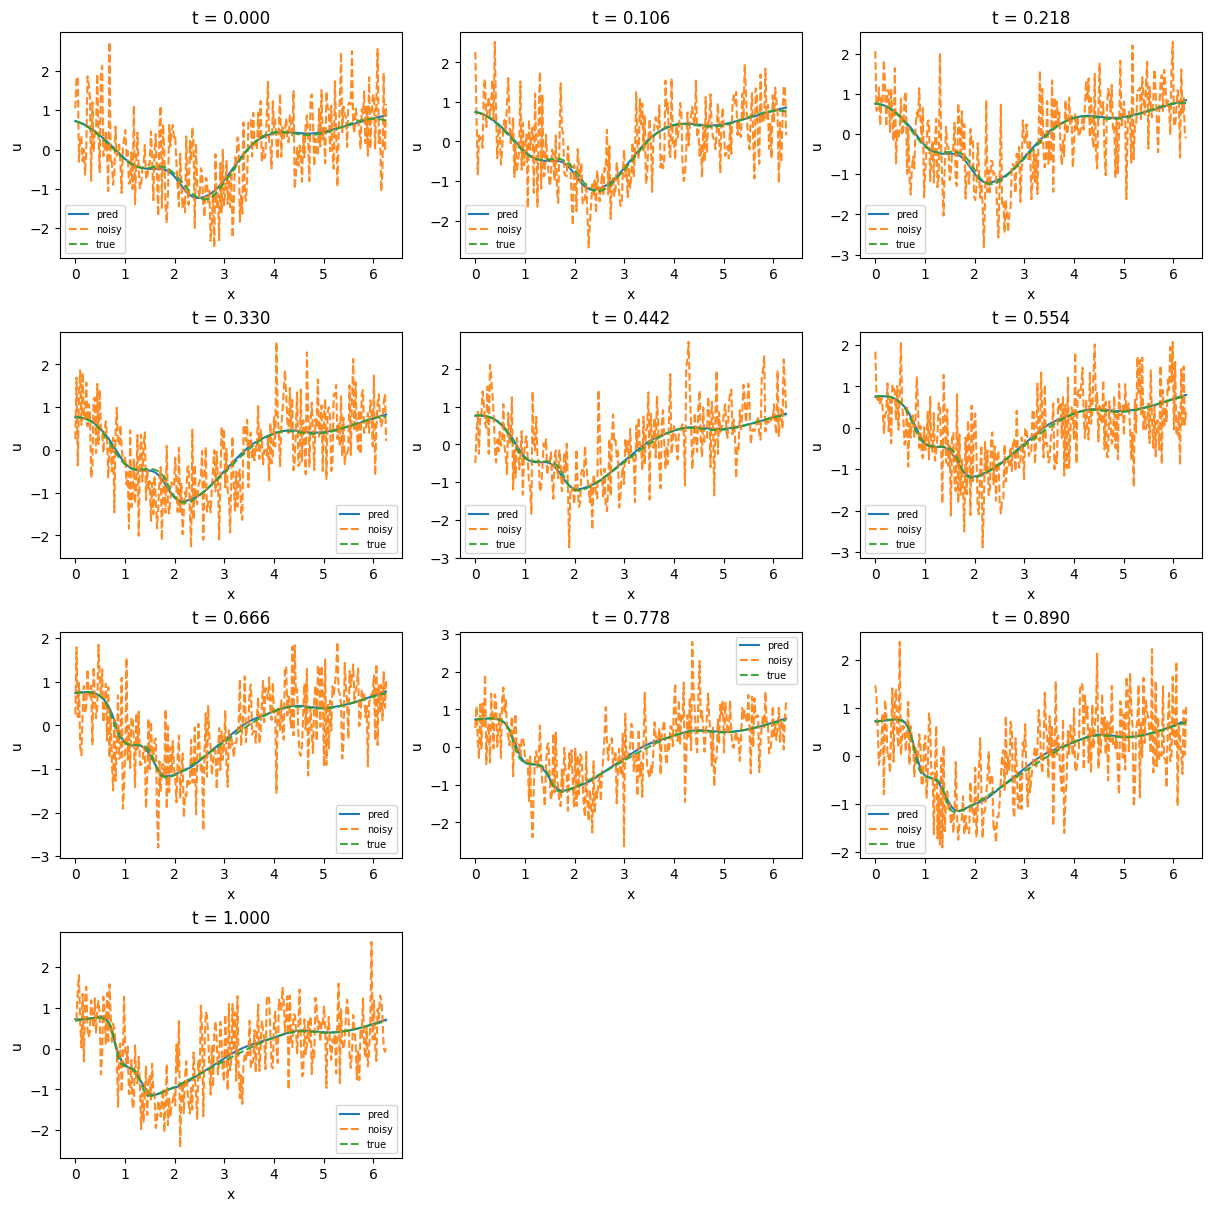

In [ ]:
#Coefficient array (outerproduct: [u,u_x,u_xx]^2)
print(symnet.effective_quadratic_matrix()) # already acted on by readout weight
print(symnet.readout.weight) #verify nu value
hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]


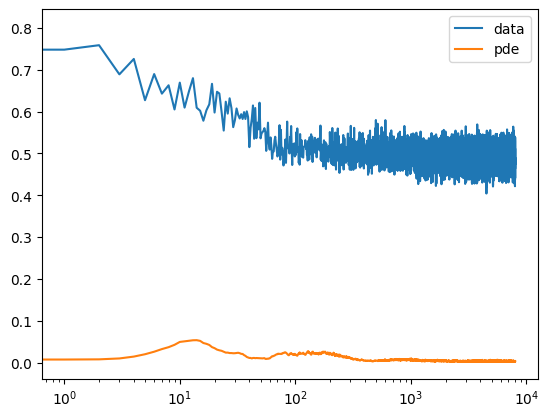

In [ ]:
plt.plot(loss_dat,label='data')
plt.plot(loss_ps,label='pde')
plt.legend()
plt.xscale('log')

To make the data sparser, set stride_x higher. Keep stride_t small so that u_t is an accurate ground truth in the calculation of pde loss. The objective in high noise regimes is to find a data fit that minimizes pde loss. 

Test: 0.7 noise (with increased stride_x)

In [8]:
# Data generation settings

noise=0.7
nu=0.02
stride_t=10
stride_x=10
part_num=1
which_part=1
seed=1432


# Dataset building

partitions = mc.build_dataset_from_burgers(noise_level=noise, nu=nu, stride_t=stride_t, stride_x=stride_x, seed=seed, quantile_splits=part_num, return_partitions=True)
t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]
# batches are generated over t_np, x_np, y_np, y_noisy_np

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

In [9]:
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64)
symnet=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False) # dummy v_model for working code
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=symnet,cfg=train_config, feature_builder=feature_builder)

In [11]:
loss_ps = []
loss_dat = []
for i in range(4000): 
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,t_torch=t_torch,x_torch=x_torch,y_noisy=y_noisy_torch,y_clean=y_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    loss_dat.append(ld)
    loss_ps.append(lp)
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

step 0 data_loss=0.4762614965438843 pde_loss=0.04546106234192848
step 1000 data_loss=0.48563605546951294 pde_loss=0.11671743541955948
step 2000 data_loss=0.5016387104988098 pde_loss=0.12260665744543076
step 3000 data_loss=0.4556145668029785 pde_loss=0.13867349922657013


tensor([[ 3.3164e-01, -7.7293e-01,  3.6374e-02],
        [ 1.6199e-03, -3.7754e-03,  1.7767e-04],
        [ 1.6074e-03, -3.7464e-03,  1.7631e-04]])
Parameter containing:
tensor([[-0.2257, -0.1372,  0.0045, -0.4790]], requires_grad=True)
max_abs_diff = 0.721647


()

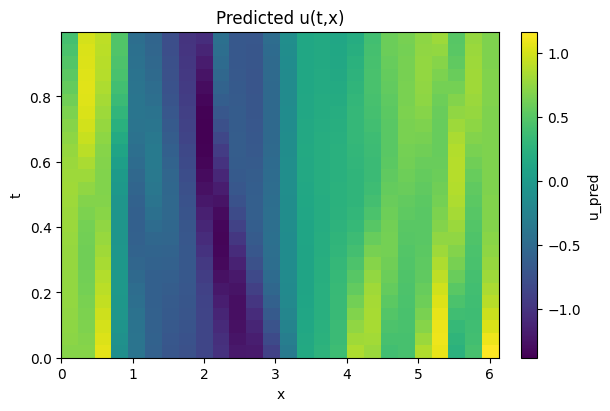

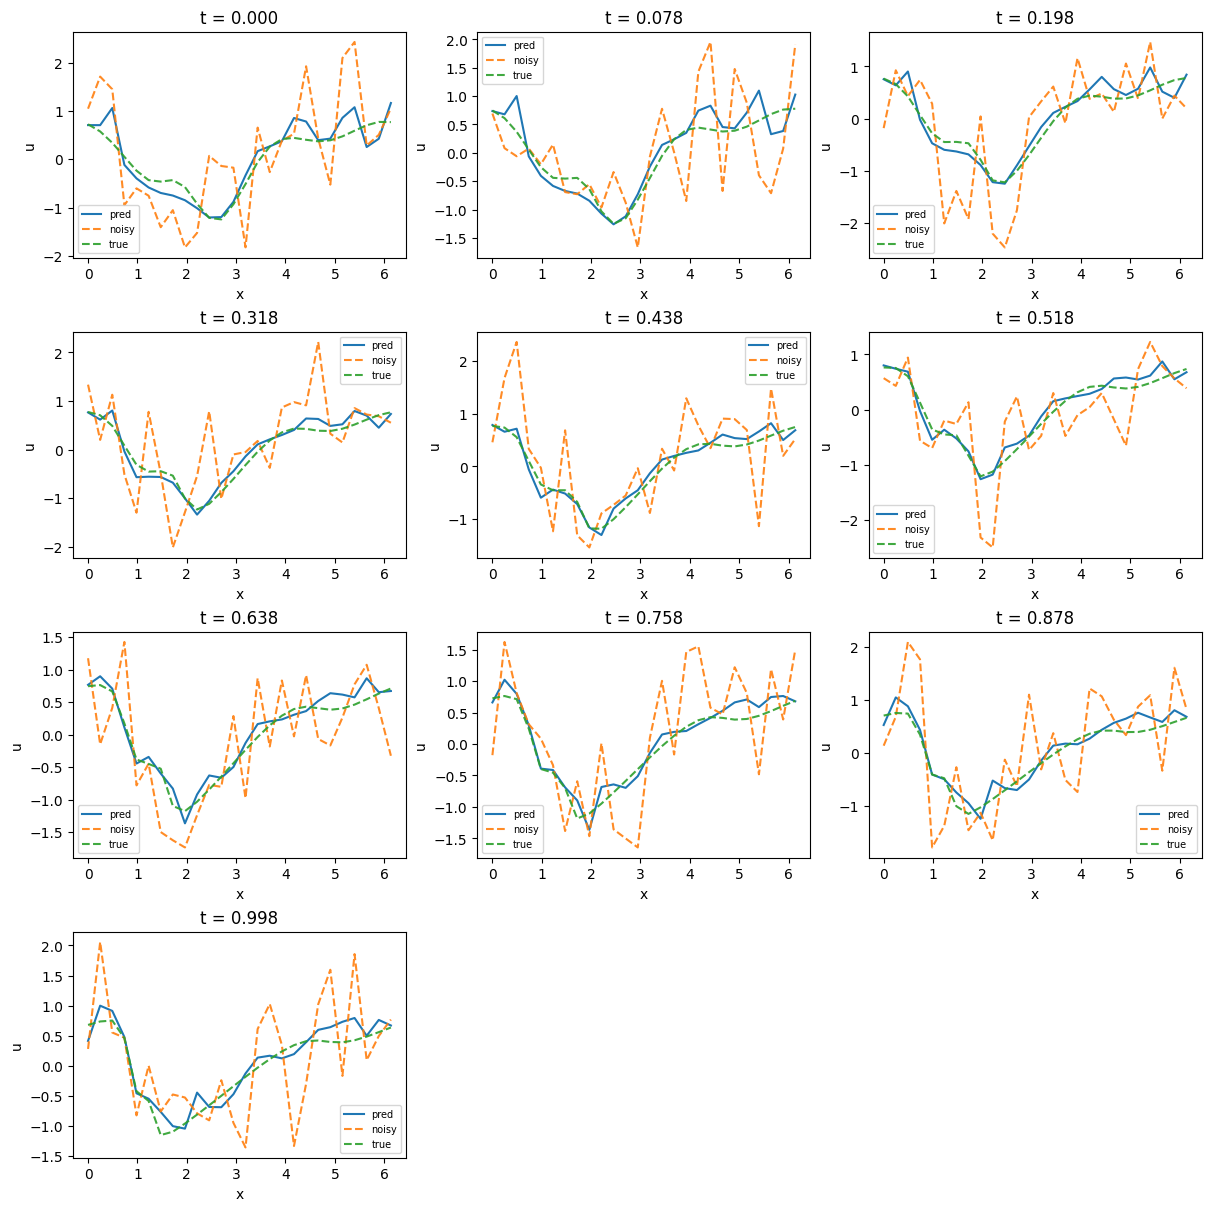

In [12]:
#Coefficient array (outerproduct: [u,u_x,u_xx]^2)
print(symnet.effective_quadratic_matrix()) # already acted on by readout weight
print(symnet.readout.weight) #verify nu value
hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]


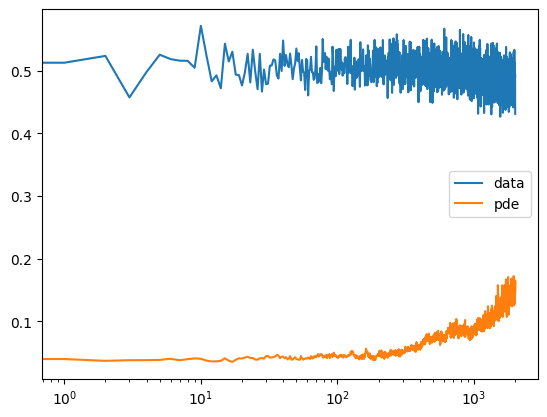

In [ ]:
plt.plot(loss_dat,label='data')
plt.plot(loss_ps,label='pde')
plt.legend()
plt.xscale('log')

We can take a look at derivatives to get an idea of why our pde values are missing. 

Max difference at index: 7
ux_fd[7] = 0.5436619725150738
ux_agclip[7] = 3.8680357933044434
Max diff occurs at x=1.718058466911316


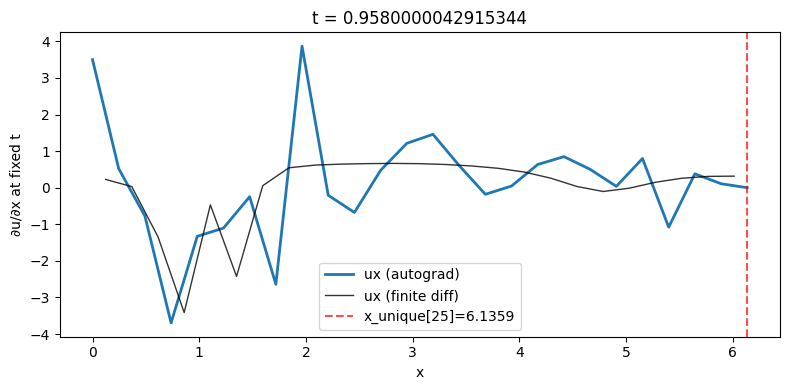

In [13]:
### DIFF TESTS ###  
# --- 1) Build sorted unique axes ---
t_unique = np.unique(t_np)
x_unique = np.unique(x_np)
Nt, Nx = len(t_unique), len(x_unique)

# --- 2) Map flattened samples into a (Nt, Nx) grid ---
# This is robust to ordering: we place each (t,x) into its index.
t_to_i = {v: i for i, v in enumerate(t_unique)}
x_to_j = {v: j for j, v in enumerate(x_unique)}

U = np.empty((Nt, Nx), dtype=np.float64)
U[:] = np.nan

for tt, xx, yy in zip(t_np, x_np, y_np):
    U[t_to_i[tt], x_to_j[xx]] = yy


# --- 3) Choose a time slice k ---
k = Nt-2             # middle time, change as you like
t0 = t_unique[k]
u_row = U[k, :]           # u(t0, x_j)

# --- 4) Finite difference du/dx along x on that slice ---
dx = np.diff(x_unique) 
du = np.diff(u_row)
ux_fd = du / dx
x_mid = 0.5 * (x_unique[1:] + x_unique[:-1])  # centers for plotting FD

# --- 5) Autograd du/dx on the same slice ---
x_t = torch.tensor(x_unique, dtype=torch.float32, device=device, requires_grad=True).unsqueeze(1)
t_t = torch.full_like(x_t, float(t0))  # same t0 for all x

u_out = train.u(t_t, x_t)         # (Nx, 1)
ux_ag = torch.autograd.grad(
    u_out, x_t,
    grad_outputs=torch.ones_like(u_out),
    create_graph=False,
    retain_graph=False
)[0].detach().cpu().numpy().ravel()

ux_agclip=ux_ag[1:]
np.linalg.norm(ux_fd-ux_agclip, ord=np.inf),max(ux_fd-ux_agclip)
max_diff_idx = np.argmax(np.abs(ux_fd - ux_agclip))
print(f"Max difference at index: {max_diff_idx}")
print(f"ux_fd[{max_diff_idx}] = {ux_fd[max_diff_idx]}")
print(f"ux_agclip[{max_diff_idx}] = {ux_agclip[max_diff_idx]}")
print(f"Max diff occurs at x={x_unique[max_diff_idx]}")

# --- 6) Plot (note: FD is length Nx-1, autograd is length Nx) ---
plt.figure(figsize=(8,4))
plt.plot(x_unique, ux_ag, label='ux (autograd)', linewidth=2)
plt.plot(x_mid, ux_fd, label='ux (finite diff)', linewidth=1, alpha=0.8, color='black')
plt.axvline(x=x_unique[25], color='red', linestyle='--', alpha=0.7, label=f'x_unique[25]={x_unique[25]:.4f}')
plt.xlabel('x')
plt.ylabel('∂u/∂x at fixed t')
plt.title(f"t = {t0}")
plt.legend()
plt.tight_layout()
plt.show()



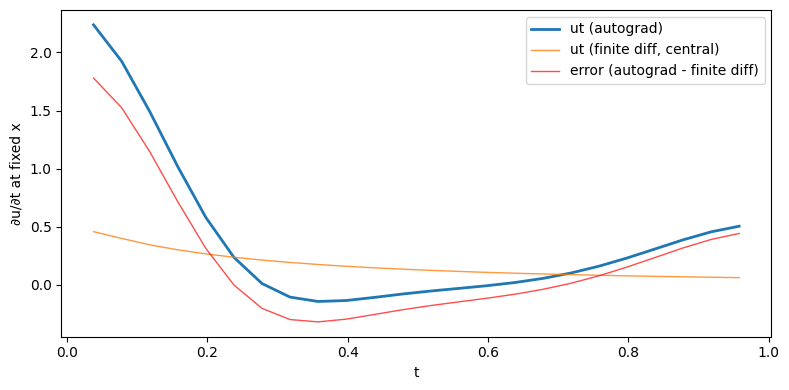

rel L2: 0.7992010106705194
Linf : 1.7794389546045368


In [ ]:
def grad1(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y), create_graph=True, retain_graph=True
    )[0]

# pick a fixed x0 (one of your grid x values)
x0 = float(x_unique[Nx // 2])  # middle x; or choose any

t_t = torch.tensor(t_unique, dtype=torch.float32, device=device, requires_grad=True).unsqueeze(1)  # (Nt,1)
x_t = torch.full_like(t_t, x0)  # same x0 for all t

u_out = train.u(t_t, x_t)  # (Nt,1)
ut = grad1(u_out, t_t)          # (Nt,1)

ut_np = ut.detach().cpu().numpy().ravel()

# index for x0
j0 = np.where(x_unique == x0)[0][0]

u_tseries = U[:, j0]        # shape (Nt,)
dt = np.diff(t_unique)

ut_fd = np.diff(u_tseries) / dt               # forward (length Nt-1)
t_mid = 0.5 * (t_unique[1:] + t_unique[:-1])  # for plotting

dt0 = t_unique[1] - t_unique[0]
ut_fd_central = (u_tseries[2:] - u_tseries[:-2]) / (4*dt0)  # length Nt-2
t_center = t_unique[1:-1]

ut_ag_trim = ut_np[1:-1]
err = ut_ag_trim - ut_fd_central

plt.figure(figsize=(8,4))
plt.plot(t_center, ut_ag_trim, label="ut (autograd)", linewidth=2)
plt.plot(t_center, ut_fd_central, label="ut (finite diff, central)", linewidth=1, alpha=0.8)
plt.plot(t_center, err, label="error (autograd - finite diff)", linewidth=1, alpha=0.7, color='red')
plt.xlabel("t")
plt.ylabel("∂u/∂t at fixed x")
plt.legend()
plt.tight_layout()
plt.show()

print("rel L2:", np.linalg.norm(err)/np.linalg.norm(ut_ag_trim))
print("Linf :", np.linalg.norm(err, np.inf))

Derivatives have an oscillatory behavior when compared to finite difference. 


In [5]:
# Data generation settings

noise=0.7
nu=0.02
stride_t=10
stride_x=10
part_num=1
which_part=1
seed=1432


# Dataset building

partitions = mc.build_dataset_from_burgers(noise_level=noise, nu=nu, stride_t=stride_t, stride_x=stride_x, seed=seed, quantile_splits=part_num, return_partitions=True)
t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]
# batches are generated over t_np, x_np, y_np, y_noisy_np

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

In [14]:
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64,act=mlps.Sin)
symnet=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False) # dummy v_model for working code
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=symnet,cfg=train_config, feature_builder=feature_builder)

In [16]:
train_config.lambda_pde = 0.5
train_config.lambda_data = 10.0
train_config.lambda_tv = 1.0
for params in u_model.parameters(): 
    params.requires_grad = True
for params in symnet.parameters(): 
    params.requires_grad = True

In [19]:
loss_ps = []
loss_dat = []
for i in range(4000): 
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,t_torch=t_torch,x_torch=x_torch, y_clean=y_torch, y_noisy=y_noisy_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    loss_dat.append(ld)
    loss_ps.append(lp)
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

step 0 data_loss=0.51385897397995 pde_loss=0.10545606166124344
step 1000 data_loss=0.48106110095977783 pde_loss=0.10472835600376129
step 2000 data_loss=0.5151469707489014 pde_loss=0.1207946315407753
step 3000 data_loss=0.4623185992240906 pde_loss=0.10595410317182541


tensor([[ 2.8442e-01, -8.0403e-03, -2.1196e-04],
        [-7.0875e-01,  2.0036e-02,  5.2819e-04],
        [ 2.4889e-02, -7.0359e-04, -1.8548e-05]])
Parameter containing:
tensor([[ 0.1089,  0.1543, -0.0027, -0.7600]], requires_grad=True)
max_abs_diff = 0.888122


()

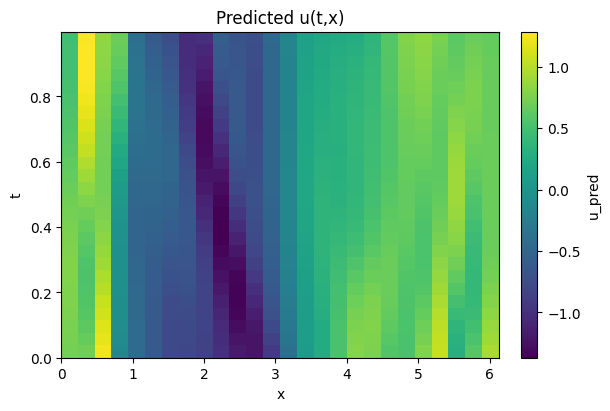

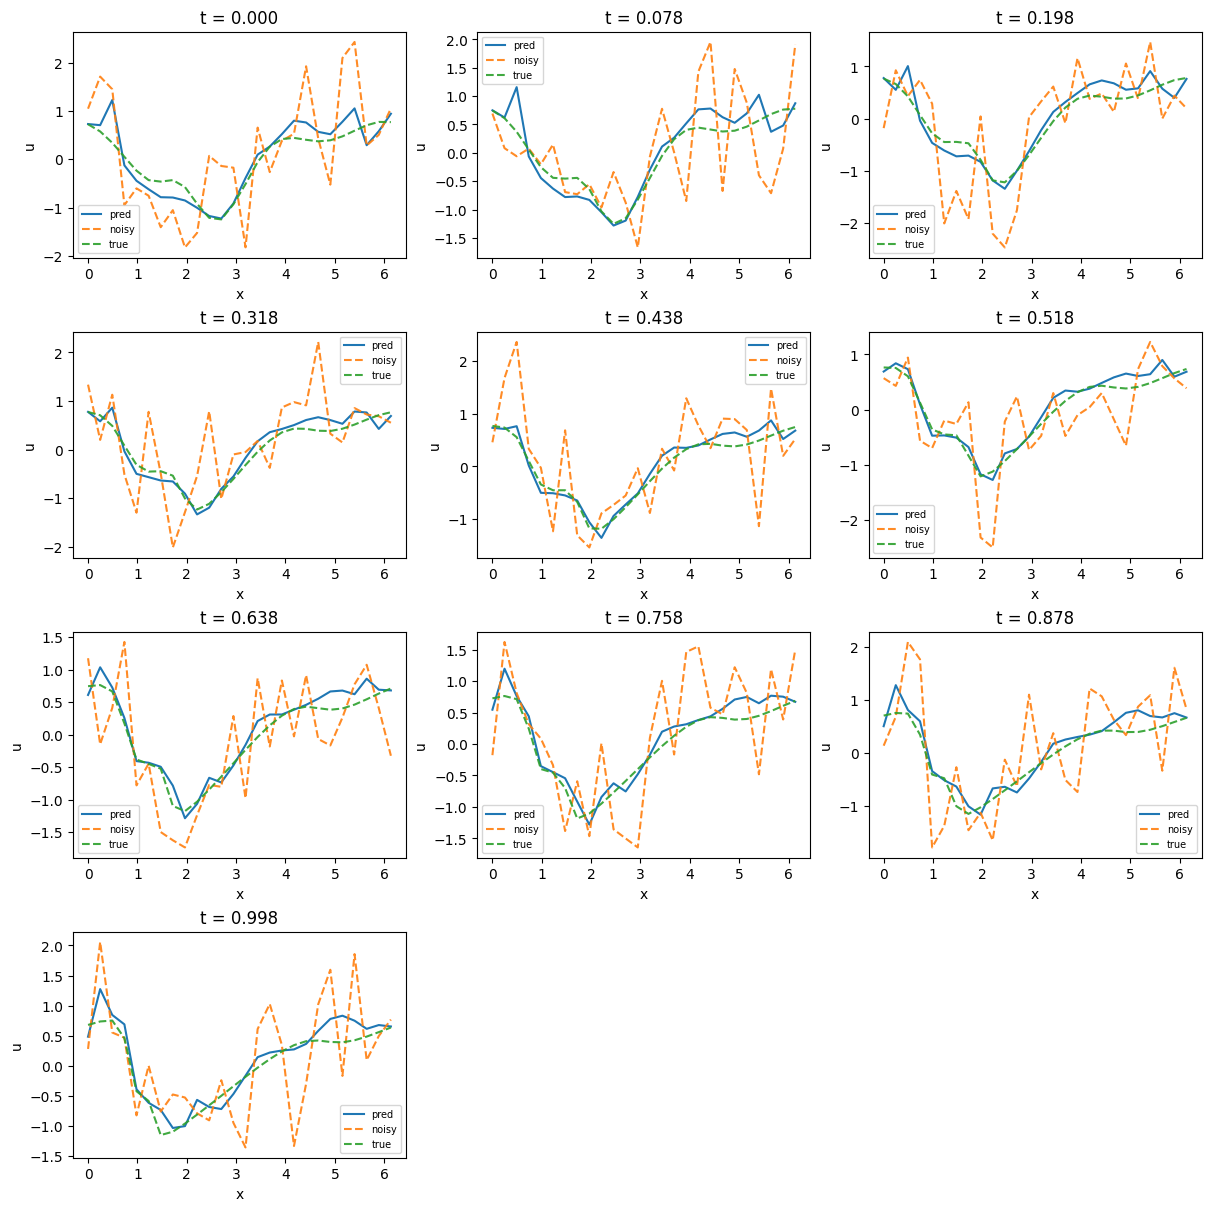

In [20]:
#Coefficient array (outerproduct: [u,u_x,u_xx]^2)
print(symnet.effective_quadratic_matrix()) # already acted on by readout weight
print(symnet.readout.weight) #verify nu value
hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]


Max difference at index: 32
ux_fd[32] = -6.208283548742757
ux_agclip[32] = -3.7182092666625977
Max diff occurs at x=0.7853981852531433


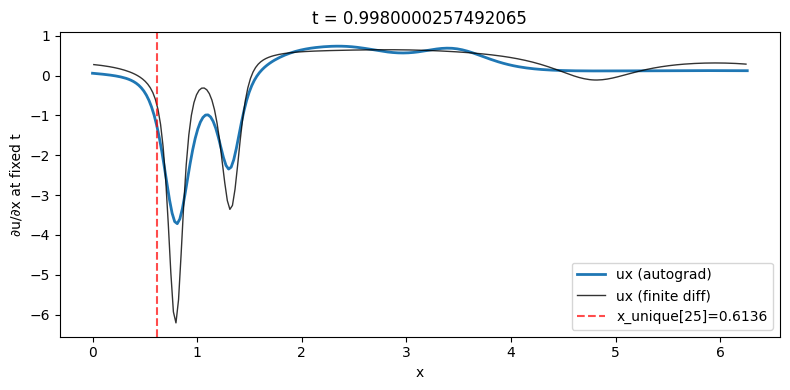

In [ ]:
### DIFF TESTS ###  
# --- 1) Build sorted unique axes ---
t_unique = np.unique(t_np)
x_unique = np.unique(x_np)
Nt, Nx = len(t_unique), len(x_unique)

# --- 2) Map flattened samples into a (Nt, Nx) grid ---
# This is robust to ordering: we place each (t,x) into its index.
t_to_i = {v: i for i, v in enumerate(t_unique)}
x_to_j = {v: j for j, v in enumerate(x_unique)}

U = np.empty((Nt, Nx), dtype=np.float64)
U[:] = np.nan

for tt, xx, yy in zip(t_np, x_np, y_np):
    U[t_to_i[tt], x_to_j[xx]] = yy


# --- 3) Choose a time slice k ---
k = Nt-2             # middle time, change as you like
t0 = t_unique[k]
u_row = U[k, :]           # u(t0, x_j)

# --- 4) Finite difference du/dx along x on that slice ---
dx = np.diff(x_unique) 
du = np.diff(u_row)
ux_fd = du / dx
x_mid = 0.5 * (x_unique[1:] + x_unique[:-1])  # centers for plotting FD

# --- 5) Autograd du/dx on the same slice ---
x_t = torch.tensor(x_unique, dtype=torch.float32, device=device, requires_grad=True).unsqueeze(1)
t_t = torch.full_like(x_t, float(t0))  # same t0 for all x

u_out = train.u(t_t, x_t)         # (Nx, 1)
ux_ag = torch.autograd.grad(
    u_out, x_t,
    grad_outputs=torch.ones_like(u_out),
    create_graph=False,
    retain_graph=False
)[0].detach().cpu().numpy().ravel()

ux_agclip=ux_ag[1:]
np.linalg.norm(ux_fd-ux_agclip, ord=np.inf),max(ux_fd-ux_agclip)
max_diff_idx = np.argmax(np.abs(ux_fd - ux_agclip))
print(f"Max difference at index: {max_diff_idx}")
print(f"ux_fd[{max_diff_idx}] = {ux_fd[max_diff_idx]}")
print(f"ux_agclip[{max_diff_idx}] = {ux_agclip[max_diff_idx]}")
print(f"Max diff occurs at x={x_unique[max_diff_idx]}")

# --- 6) Plot (note: FD is length Nx-1, autograd is length Nx) ---
plt.figure(figsize=(8,4))
plt.plot(x_unique, ux_ag, label='ux (autograd)', linewidth=2)
plt.plot(x_mid, ux_fd, label='ux (finite diff)', linewidth=1, alpha=0.8, color='black')
plt.axvline(x=x_unique[25], color='red', linestyle='--', alpha=0.7, label=f'x_unique[25]={x_unique[25]:.4f}')
plt.xlabel('x')
plt.ylabel('∂u/∂x at fixed t')
plt.title(f"t = {t0}")
plt.legend()
plt.tight_layout()
plt.show()



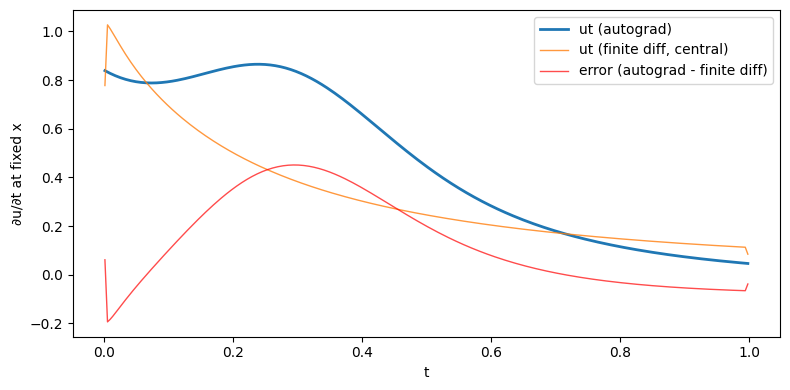

rel L2: 0.40875103382811684
Linf : 0.4511394387289561


In [ ]:
def grad1(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y), create_graph=True, retain_graph=True
    )[0]

# pick a fixed x0 (one of your grid x values)
x0 = float(x_unique[Nx // 2])  # middle x; or choose any

t_t = torch.tensor(t_unique, dtype=torch.float32, device=device, requires_grad=True).unsqueeze(1)  # (Nt,1)
x_t = torch.full_like(t_t, x0)  # same x0 for all t

u_out = train.u(t_t, x_t)  # (Nt,1)
ut = grad1(u_out, t_t)          # (Nt,1)

ut_np = ut.detach().cpu().numpy().ravel()

# index for x0
j0 = np.where(x_unique == x0)[0][0]

u_tseries = U[:, j0]        # shape (Nt,)
dt = np.diff(t_unique)

ut_fd = np.diff(u_tseries) / dt               # forward (length Nt-1)
t_mid = 0.5 * (t_unique[1:] + t_unique[:-1])  # for plotting

dt0 = t_unique[1] - t_unique[0]
ut_fd_central = (u_tseries[2:] - u_tseries[:-2]) / (4*dt0)  # length Nt-2
t_center = t_unique[1:-1]

ut_ag_trim = ut_np[1:-1]
err = ut_ag_trim - ut_fd_central

plt.figure(figsize=(8,4))
plt.plot(t_center, ut_ag_trim, label="ut (autograd)", linewidth=2)
plt.plot(t_center, ut_fd_central, label="ut (finite diff, central)", linewidth=1, alpha=0.8)
plt.plot(t_center, err, label="error (autograd - finite diff)", linewidth=1, alpha=0.7, color='red')
plt.xlabel("t")
plt.ylabel("∂u/∂t at fixed x")
plt.legend()
plt.tight_layout()
plt.show()

print("rel L2:", np.linalg.norm(err)/np.linalg.norm(ut_ag_trim))
print("Linf :", np.linalg.norm(err, np.inf))

{'loss': 3.322373867034912, 'loss_data': 0.3201642632484436, 'loss_pde': 0.2414625585079193, 'l1': 5.422179698944092, 'loss_tv': 0.0, 'feature_names': ['u', 'u_x', 'u_xx'], 'feature_scales': tensor([1., 1., 1.])}
{'loss': 2.9849355220794678, 'loss_data': 0.28886163234710693, 'loss_pde': 0.19263848662376404, 'l1': 6.3206467628479, 'loss_tv': 0.0, 'feature_names': ['u', 'u_x', 'u_xx'], 'feature_scales': tensor([1., 1., 1.])}
{'loss': 2.8524010181427, 'loss_data': 0.27650678157806396, 'loss_pde': 0.1746663749217987, 'l1': 7.0935492515563965, 'loss_tv': 0.0, 'feature_names': ['u', 'u_x', 'u_xx'], 'feature_scales': tensor([1., 1., 1.])}
{'loss': 2.7418932914733887, 'loss_data': 0.2650279402732849, 'loss_pde': 0.18322747945785522, 'l1': 7.865354537963867, 'loss_tv': 0.0, 'feature_names': ['u', 'u_x', 'u_xx'], 'feature_scales': tensor([1., 1., 1.])}


AttributeError: module 'matplotlib' has no attribute 'animation'

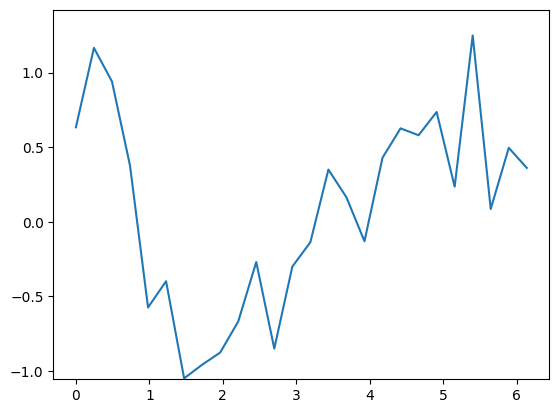

In [ ]:
snap_u = []
snap_meta = []
snap_step=10
read_step=1000

# fixed eval tensors
x_grid = np.unique(x_np)
x_eval = torch.tensor(x_grid, dtype=torch.float32, device=device).unsqueeze(1)
t_k = float(np.unique(t_np)[-2])  # or pick explicitly
t_eval = torch.full_like(x_eval, t_k)

for step in range(10000):
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    if step%read_step==0:
        print(out)
    if step%snap_step==0:
        with torch.no_grad():
            u_eval = train.u(t_eval, x_eval).detach().cpu().numpy().ravel()
        snap_u.append(u_eval)
        snap_meta.append((step, out["loss_data"], out["loss_pde"]))

# animate
fig, ax = plt.subplots()
line, = ax.plot(x_grid, snap_u[0])
ax.set_ylim(np.min(snap_u), np.max(snap_u))


In [ ]:
def update(i):
    line.set_ydata(snap_u[i])
    step, ld, lp = snap_meta[i]
    ax.set_title(f"t={t_k:.4g} step={step} data={ld:.2e} pde={lp:.2e}")
    return (line,)

ani = matplotlib.animation.FuncAnimation(fig, update, frames=len(snap_u), interval=250, blit=False)
ani.save("u_tk_training.mp4", fps=4)